In [ ]:
# =====================================================
# 📌 EXECUTIVE SUMMARY
# =====================================================
# - Forte stagionalità della domanda
# - Pricing dinamico: ADR cresce nei picchi
# - Lead time alto → maggiore rischio cancellazione
# - Clienti con più richieste speciali → più affidabili
# - Domanda dominata da soggiorni brevi e piccoli gruppi

# =====================================================
# 1. SETUP
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
# =====================================================
# 2. LOAD
# =====================================================
df = pd.read_excel("Clean Data PBI.xlsx")
print(df.head())
print(df.info())

   ID         hotel  is_canceled is_canceled_TEXT  lead_time  \
0   1  Resort Hotel            0               No        342   
1   2  Resort Hotel            0               No        737   
2   3  Resort Hotel            0               No          7   
3   4  Resort Hotel            0               No         13   
4   5  Resort Hotel            0               No         14   

   arrival_date_year arrival_date_month  arrival_date_week_number  \
0               2015               July                        27   
1               2015               July                        27   
2               2015               July                        27   
3               2015               July                        27   
4               2015               July                        27   

   arrival_date_day_of_month arrival_data  ...  deposit_type  agent  company  \
0                          1   2015-07-01  ...    No Deposit    NaN      NaN   
1                          1   2015-07-0

company             112589
arrival_data         43013
agent                16338
country                488
is_canceled_TEXT         0
dtype: int64


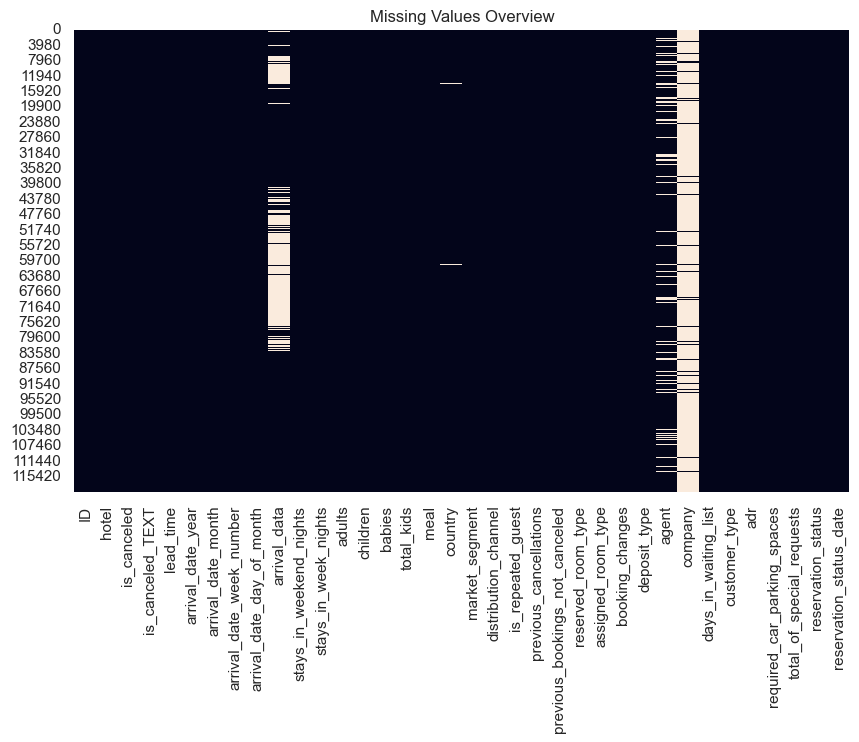

In [3]:
# =====================================================
# 3. DATA QUALITY
# =====================================================
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head())

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Overview")
plt.show()

# 🔎 Dataset pulito → pronto per analisi

In [4]:
# =====================================================
# 4. FEATURE ENGINEERING
# =====================================================
if 'total_stay' not in df.columns:
    df['total_stay'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

if 'total_guests' not in df.columns:
    df['total_guests'] = df['adults'] + df['children'] + df['babies']


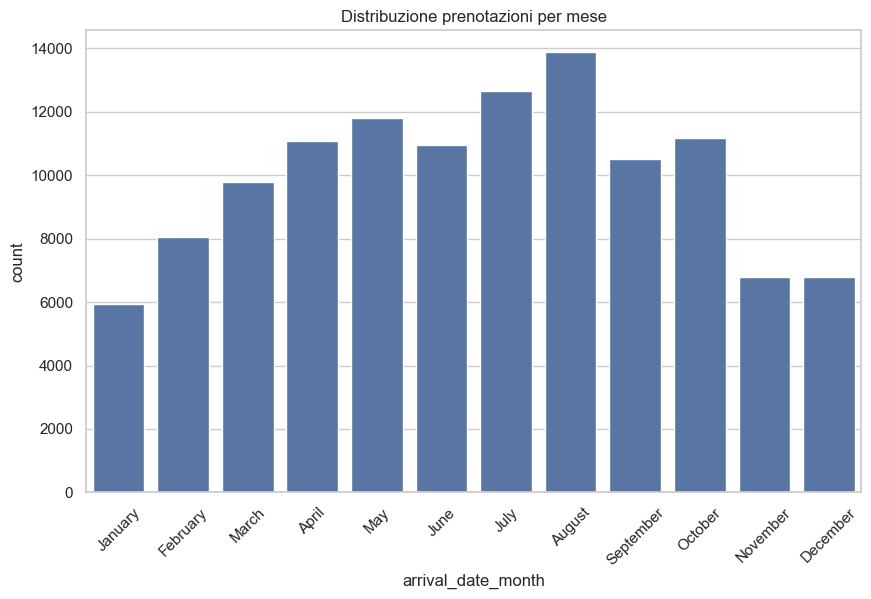

In [5]:
# =====================================================
# 5. STAGIONALITÀ
# =====================================================
if 'arrival_date_month' in df.columns:
    months = ['January','February','March','April','May','June','July','August','September','October','November','December']
    sns.countplot(x='arrival_date_month', data=df, order=months)
    plt.xticks(rotation=45)
    plt.title("Distribuzione prenotazioni per mese")
    plt.show()

# 🔎 Picchi estivi → alta domanda

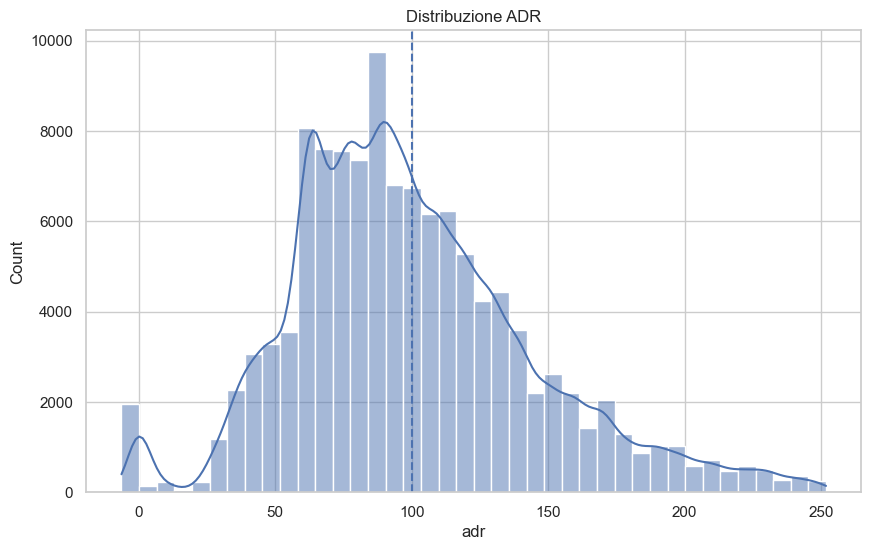

In [6]:
# =====================================================
# 6. PREZZI (ADR)
# =====================================================
if 'adr' in df.columns:
    adr_f = df[df['adr'] < df['adr'].quantile(0.99)]

    sns.histplot(adr_f['adr'], kde=True, bins=40)
    plt.axvline(adr_f['adr'].mean(), linestyle='--')
    plt.title("Distribuzione ADR")
    plt.show()

# 🔎 Distribuzione skewed → segmenti premium

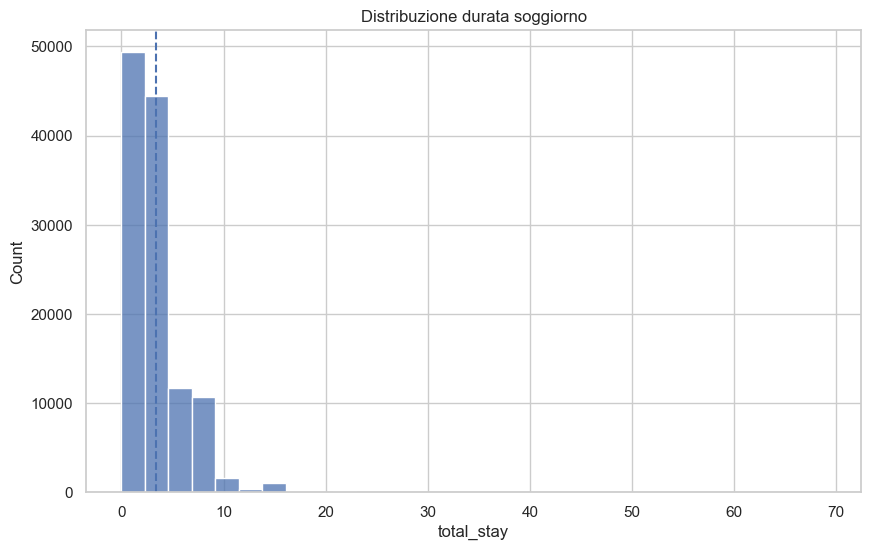

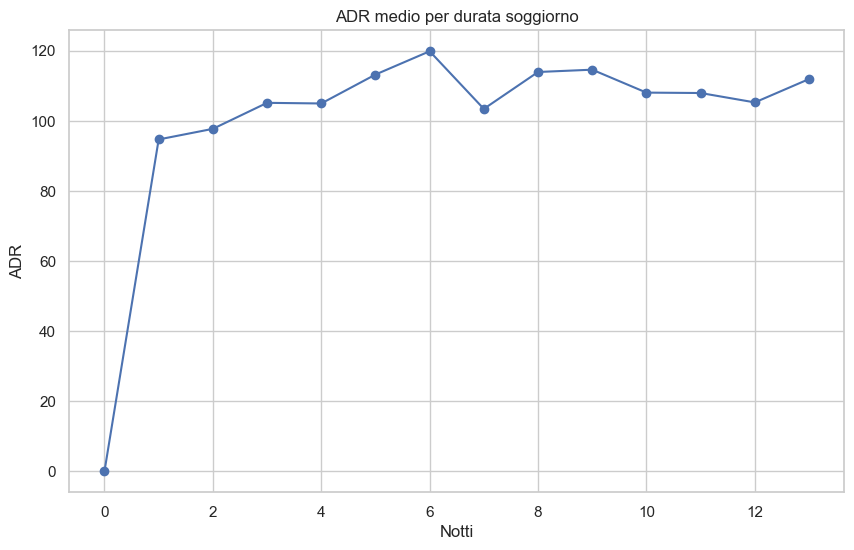

In [8]:
# =====================================================
# 7. DURATA SOGGIORNO
# =====================================================
sns.histplot(df['total_stay'], bins=30)
plt.axvline(df['total_stay'].mean(), linestyle='--')
plt.title("Distribuzione durata soggiorno")
plt.show()

# 🔎 Dominanza short stay

# Trend ADR vs durata (versione migliorata)
df_f = df[df['total_stay'] < df['total_stay'].quantile(0.99)]
adr_by_stay = df_f.groupby('total_stay')['adr'].mean()

adr_by_stay.plot(marker='o')
plt.title("ADR medio per durata soggiorno")
plt.xlabel("Notti")
plt.ylabel("ADR")
plt.show()

# 🔎 Tendenza a sconti per soggiorni lunghi

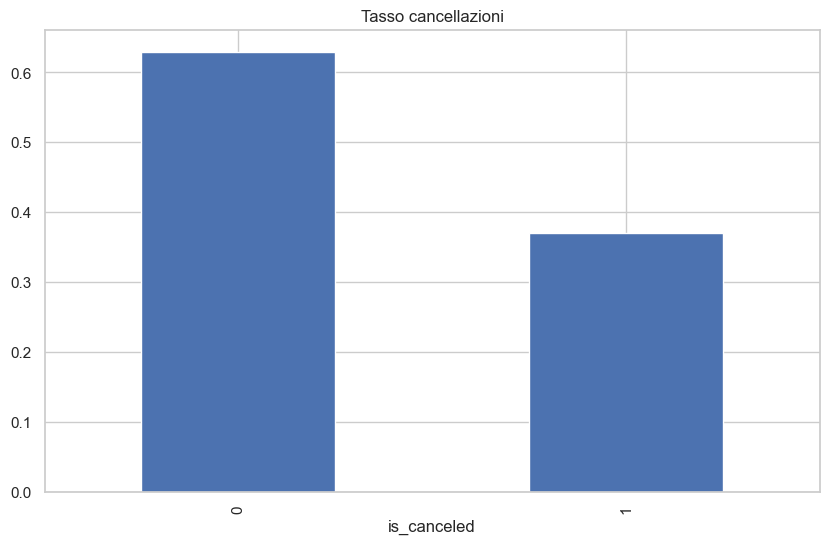

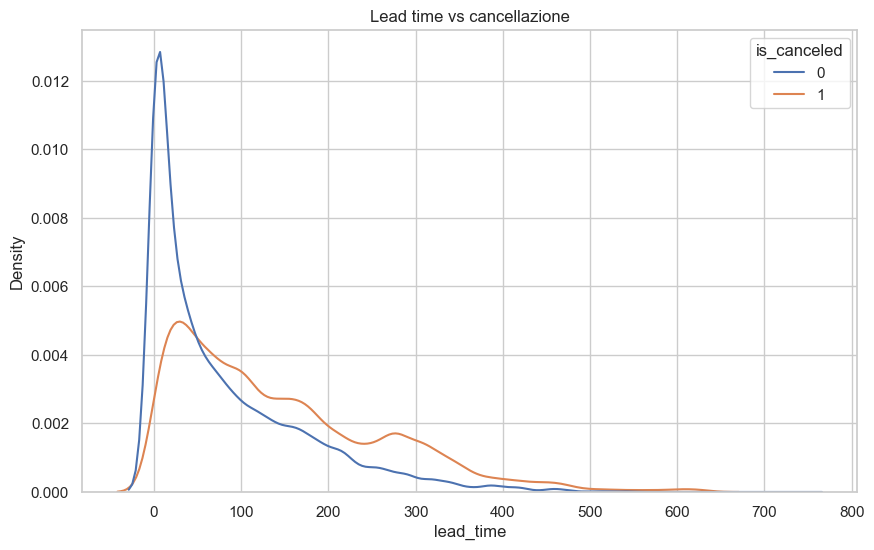

In [9]:
# =====================================================
# 8. CANCELLAZIONI
# =====================================================
if 'is_canceled' in df.columns:
    rate = df['is_canceled'].value_counts(normalize=True)
    rate.plot(kind='bar')
    plt.title("Tasso cancellazioni")
    plt.show()

    sns.kdeplot(data=df, x='lead_time', hue='is_canceled', common_norm=False)
    plt.title("Lead time vs cancellazione")
    plt.show()

# 🔎 Lead time alto → più cancellazioni

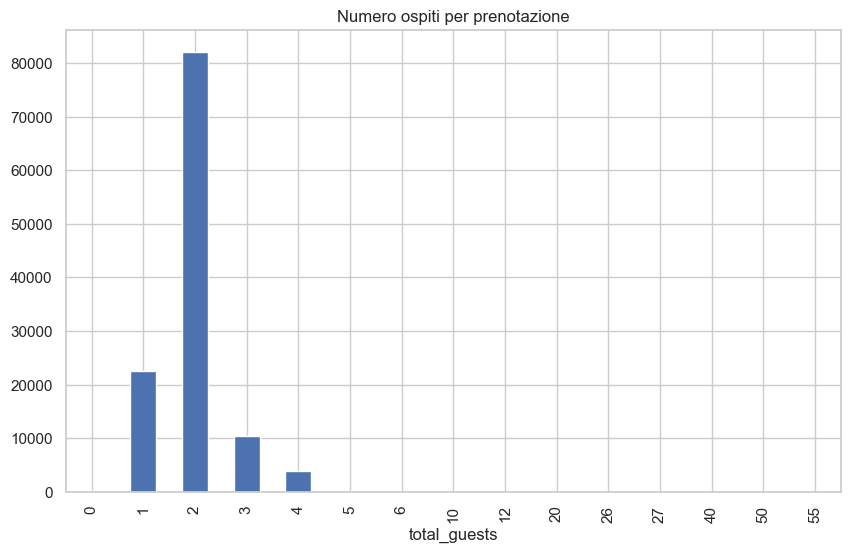

In [10]:
# =====================================================
# 9. CLIENT PROFILE
# =====================================================
guests = df['total_guests'].value_counts().sort_index()
guests.plot(kind='bar')
plt.title("Numero ospiti per prenotazione")
plt.show()

# 🔎 Dominano coppie/singoli

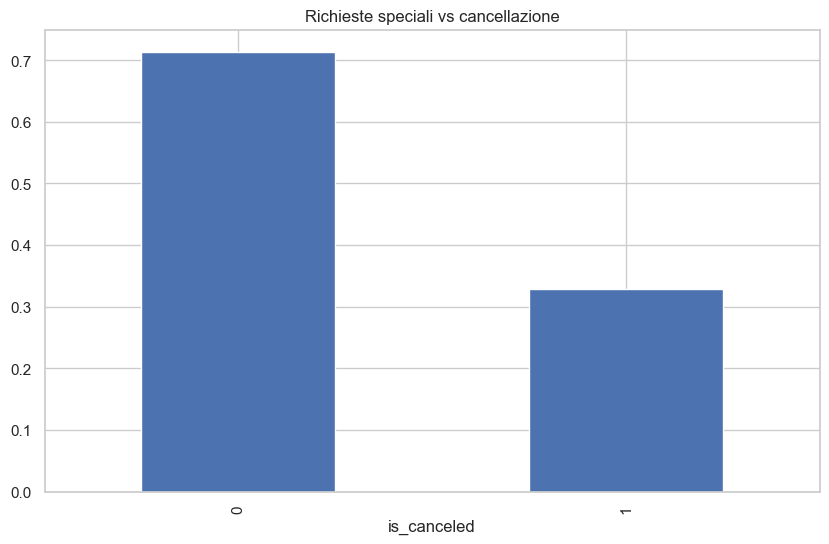

In [11]:
# =====================================================
# 10. SPECIAL REQUESTS
# =====================================================
if 'is_canceled' in df.columns:
    req_mean = df.groupby('is_canceled')['total_of_special_requests'].mean()
    req_mean.plot(kind='bar')
    plt.title("Richieste speciali vs cancellazione")
    plt.show()

# 🔎 Più richieste → meno cancellazioni

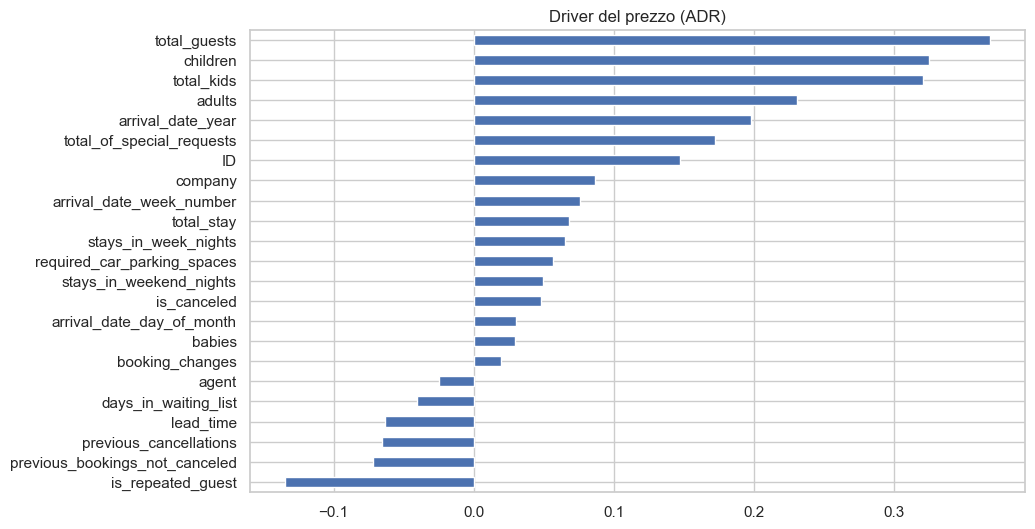

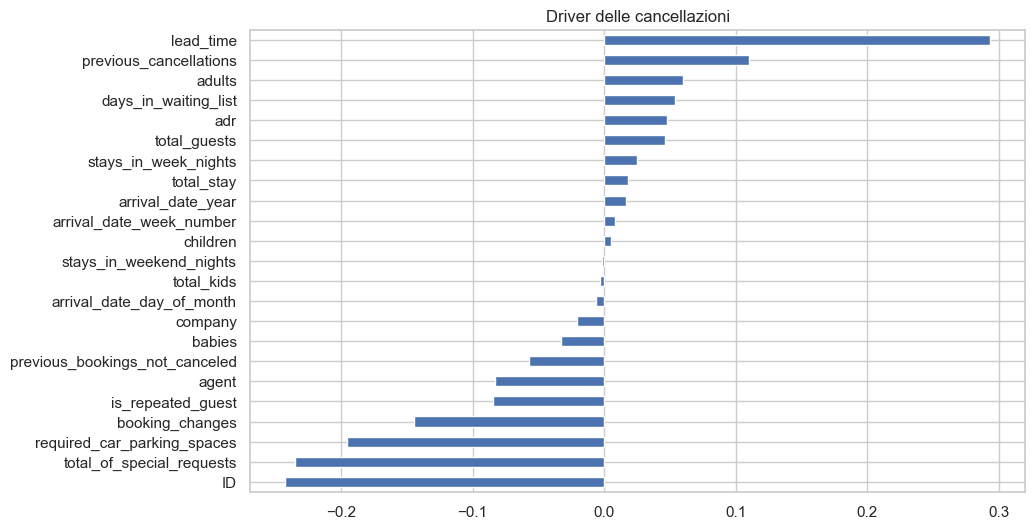

In [12]:
# =====================================================
# 11. DRIVER ANALYSIS (NO HEATMAP)
# =====================================================

# ADR drivers
corr_adr = df.corr(numeric_only=True)['adr'].drop('adr').sort_values()
corr_adr.plot(kind='barh')
plt.title("Driver del prezzo (ADR)")
plt.show()

# Cancellation drivers
corr_c = df.corr(numeric_only=True)['is_canceled'].drop('is_canceled').sort_values()
corr_c.plot(kind='barh')
plt.title("Driver delle cancellazioni")
plt.show()

# 🔎 Focus su insight → non rumore


In [ ]:
# =====================================================
# 12. CONCLUSIONI STRATEGICHE
# =====================================================

# - Pricing dinamico efficace
# - Lead time variabile critica
# - Segmentazione clienti necessaria
# - Opportunità su soggiorni lunghi